1. Importar librerías de ML y conectar a la BD

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

sns.set_theme(style="whitegrid")

# Conexión a la BD
load_dotenv('../.env')
engine = create_engine(f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}")

print("✅ Librerías de Machine Learning cargadas.")

C:\Users\Andres\AppData\Local\Temp\ipykernel_21368\1013820788.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


✅ Librerías de Machine Learning cargadas.


2. Extraer los datos pre-procesados de nuestra Vista SQL

In [2]:
query = "SELECT * FROM vw_customer_rfm_prep;"
df_rfm = pd.read_sql(query, engine)

# Llenar valores nulos por si algún cliente no tiene compras (monetary = 0)
df_rfm = df_rfm.fillna({'frequency': 0, 'monetary': 0, 'recency_dias': 999})

print(f"Total de clientes listos para segmentar: {len(df_rfm)}")
df_rfm.head()

Total de clientes listos para segmentar: 326


,id_cliente,nombre,apellido,ultima_compra,recency_dias,frequency,monetary
0,1,Karisa,Cromett,2024-12-13,642.0,11,287.77
1,2,Lenette,Seabert,2024-11-15,670.0,3,103.28
2,3,Buddy,Silverson,2024-12-08,647.0,7,160.24
3,4,Dan,Parkin,2024-12-01,654.0,7,230.16
4,5,Conney,Cassella,2024-12-11,644.0,7,164.48


3. Normalización de los Datos (Paso CRÍTICO en ML)

¿Por qué hacemos esto? El modelo K-Means calcula distancias matemáticas. monetary puede estar en miles (ej. $2,000), mientras que frequency está en unidades pequeñas (ej. 3 compras). Si no los igualamos, el modelo solo le hará caso al dinero y va a ignorar la frecuencia.

In [3]:
# Seleccionamos solo las variables numéricas para el modelo
features = ['recency_dias', 'frequency', 'monetary']
X = df_rfm[features]

# Normalizamos para que todas las variables tengan la misma "escala" (media 0, varianza 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Datos normalizados. Primer cliente (escalado):", X_scaled[0])

Datos normalizados. Primer cliente (escalado): [-0.60755769  1.21426413  0.15822159]


4. El Método del Codo (Elbow Method)

¿Cuántos segmentos (clusters) deberíamos crear? El método del codo nos ayuda a descubrir el número matemático óptimo probando de 1 a 10 grupos.

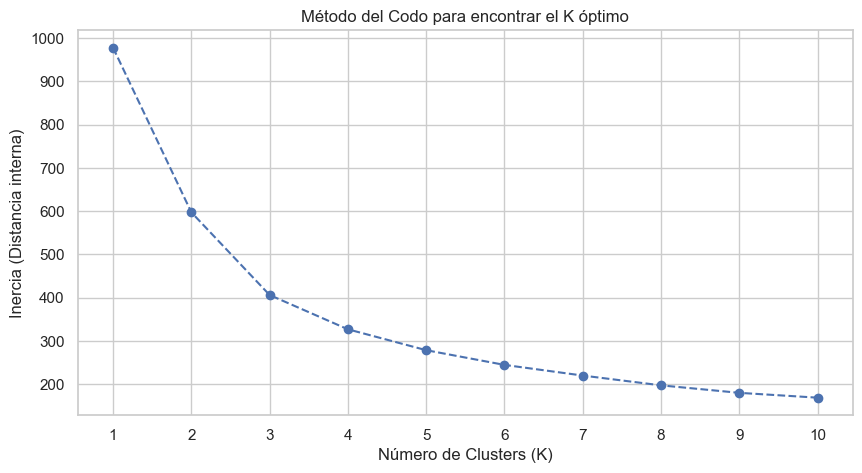

In [4]:
inercia = []
rango_k = range(1, 11)

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inercia.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(rango_k, inercia, marker='o', linestyle='--')
plt.title('Método del Codo para encontrar el K óptimo')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia (Distancia interna)')
plt.xticks(rango_k)
plt.show()

Interpretación: Debes buscar el punto donde la curva hace un "codo" y deja de bajar drásticamente. Generalmente, 3 o 4 clusters son ideales para negocios minoristas. Usaremos 4 clusters para tener: VIPs, Frecuentes, Ocasionales y En Riesgo.

5. Entrenar el Modelo K-Means

In [5]:
# Entrenamos el modelo definitivo con 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_rfm['cluster'] = kmeans.fit_predict(X_scaled)

# Calcular el promedio de R, F y M para cada cluster para entender quiénes son
cluster_profile = df_rfm.groupby('cluster')[['recency_dias', 'frequency', 'monetary']].mean().round(2)
cluster_profile['cantidad_clientes'] = df_rfm['cluster'].value_counts()

display(cluster_profile.sort_values(by='monetary', ascending=False))

,recency_dias,frequency,monetary,cantidad_clientes
cluster,,,,
2,647.00,11.79,456.85,52
3,654.75,8.63,297.92,118
1,735.73,5.66,189.65,59
0,649.30,5.75,181.76,97


6. Asignar Nombres de Negocio (Business Labels)

Los modelos de ML devuelven números (Cluster 0, 1, 2, 3). Nosotros como analistas debemos traducir eso a negocio. Basado en el monetary promedio (ordenado de mayor a menor), vamos a bautizarlos.

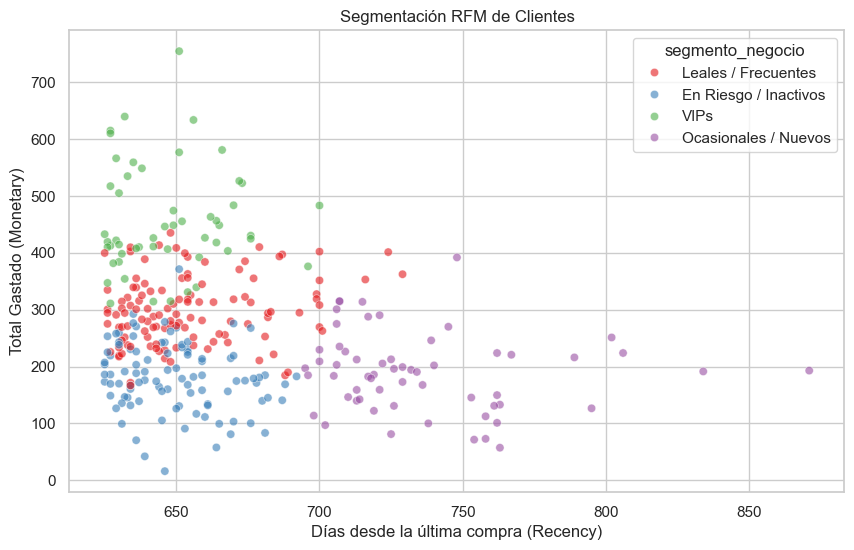

In [6]:
# Ordenar los clusters por gasto monetario (del que gasta más al que gasta menos)
sorted_clusters = cluster_profile.sort_values(by='monetary', ascending=False).index

# Crear un diccionario para renombrar los clusters lógicamente
nombres_segmentos = {
    sorted_clusters[0]: 'VIPs',
    sorted_clusters[1]: 'Leales / Frecuentes',
    sorted_clusters[2]: 'Ocasionales / Nuevos',
    sorted_clusters[3]: 'En Riesgo / Inactivos'
}

# Aplicar los nombres a nuestro dataset
df_rfm['segmento_negocio'] = df_rfm['cluster'].map(nombres_segmentos)

# Graficar nuestra segmentación final
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_rfm, 
    x='recency_dias', 
    y='monetary', 
    hue='segmento_negocio', 
    palette='Set1',
    alpha=0.6
)
plt.title('Segmentación RFM de Clientes')
plt.xlabel('Días desde la última compra (Recency)')
plt.ylabel('Total Gastado (Monetary)')
plt.show()

7. Guardar los resultados en PostgreSQL (Cerrando el ciclo de Data Engineering)

¡De nada sirve el ML si se queda en tu computadora! Vamos a guardar esta segmentación en la base de datos para que luego Power BI pueda leerla.

In [9]:
from sqlalchemy import text

print("📤 Guardando segmentos en PostgreSQL...")
try:
    # Guardamos solo el ID y el segmento
    df_export = df_rfm[['id_cliente', 'cluster', 'segmento_negocio']]
    
    # Lo enviamos a una nueva tabla llamada "segmentos_clientes"
    df_export.to_sql('segmentos_clientes', engine, if_exists='replace', index=False)
    
    # Le damos permisos al usuario para que pueda leerla usando sqlalchemy.text
    with engine.connect() as con:
        con.execute(text("GRANT SELECT ON segmentos_clientes TO andes_user;"))
        con.commit()
        
    print("✅ ¡Segmentación guardada con éxito en la tabla 'segmentos_clientes'!")
except Exception as e:
    print(f"❌ Error: {e}")

📤 Guardando segmentos en PostgreSQL...
✅ ¡Segmentación guardada con éxito en la tabla 'segmentos_clientes'!
